<a href="https://colab.research.google.com/github/jj-practice-star/DataScienceProjects-Sem7/blob/main/Lab1_FDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Lab 1
Importing Dataset and Loading Data.


*    df.info(): Prints a summary of the DataFrame, including the total
row count, column names, non-null counts, data types, and memory
usage.

*   print(df.shape): Prints the number of rows and columns as a tuple
(rows, columns)



In [48]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler , StandardScaler
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv('diabetesnew.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0


In [6]:
print("------------------------Shape----------------------------")
print(df.shape)
print("------------------------Types----------------------------")
print(df.dtypes)
print("------------------------Describe----------------------------")
df.describe()


------------------------Shape----------------------------
(768, 9)
------------------------Types----------------------------
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
------------------------Describe----------------------------


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
# Replace 0 with NaN for specific columns
cols_with_zeros =['Glucose', 'BloodPressure', 'SkinThickness',
'Insulin', 'BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)
for col in cols_with_zeros:
  # df[col].fillna(df[col].median(), inplace=True)
  df.fillna({col:df[col].median},inplace=True)
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,<bound method Series.median of 0 NaN\n1...,33.6,0.627,50,1
1,1,85.0,66.0,29.0,<bound method Series.median of 0 NaN\n1...,26.6,0.351,31,0
2,8,183.0,64.0,<bound method Series.median of 0 35.0\n1 ...,<bound method Series.median of 0 NaN\n1...,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [18]:
import pandas as pd
import numpy as np

zero_columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

df_clean = df.copy()

# Convert the columns from object/text to numeric
for column in zero_columns:
    df_clean[column] = pd.to_numeric(df_clean[column], errors='coerce')

# Replace 0 with NaN
df_clean[zero_columns] = df_clean[zero_columns].replace(0, np.nan)

# Create a copy for mean imputation
df_mean = df_clean.copy()

# Replace missing values with the mean of each column
for column in zero_columns:
    df_mean[column] = df_mean[column].fillna(df_mean[column].mean())

print(df_mean[zero_columns].dtypes)
print(df_mean.isnull().sum())

df_median = df_clean.copy()

for column in zero_columns:
    df_median[column] = df_median[column].fillna(df_median[column].median())

print(df_median.isnull().sum())



Glucose          float64
BloodPressure    float64
SkinThickness    float64
Insulin          float64
BMI              float64
dtype: object
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [19]:
comparison = pd.DataFrame({
    "Mean Imputation": [
        df_mean[col].mean() for col in zero_columns
    ],
    "Median Imputation": [
        df_median[col].median() for col in zero_columns
    ]
}, index=zero_columns)

print(comparison)


               Mean Imputation  Median Imputation
Glucose             121.686763              117.0
BloodPressure        72.405184               72.0
SkinThickness        29.153420               29.0
Insulin             155.548223              125.0
BMI                  32.457464               32.3


In [20]:
df_processed = df_median.copy()

In [23]:
#Check Duplicate Records
print("Duplicate Records:", df_processed.duplicated().sum())
#Remove Duplicate Records
df_processed = df_processed.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df_processed.shape)


Duplicate Records: 0
Dataset Shape After Removing Duplicates: (768, 9)


In [24]:
#Convert Data into Appropriate Formats
print(df_processed.dtypes)

df_processed = df_processed.astype({
    'Pregnancies': 'int64',
    'Glucose': 'float64',
    'BloodPressure': 'float64',
    'SkinThickness': 'float64',
    'Insulin': 'float64',
    'BMI': 'float64',
    'DiabetesPedigreeFunction': 'float64',
    'Age': 'int64',
    'Outcome': 'int64'
})


Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [25]:
#Normalization Using Min-Max Scaling

numerical_columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

min_max_scaler = MinMaxScaler()

df_normalized = df_processed.copy()

df_normalized[numerical_columns] = min_max_scaler.fit_transform(
    df_processed[numerical_columns]
)

print(df_normalized.head())


   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.352941  0.670968       0.489796       0.304348  0.133413  0.314928   
1     0.058824  0.264516       0.428571       0.239130  0.133413  0.171779   
2     0.470588  0.896774       0.408163       0.239130  0.133413  0.104294   
3     0.058824  0.290323       0.428571       0.173913  0.096154  0.202454   
4     0.000000  0.600000       0.163265       0.304348  0.185096  0.509202   

   DiabetesPedigreeFunction       Age  Outcome  
0                  0.234415  0.483333        1  
1                  0.116567  0.166667        0  
2                  0.253629  0.183333        1  
3                  0.038002  0.000000        0  
4                  0.943638  0.200000        1  


In [26]:
standard_scaler = StandardScaler()

df_standardized = df_processed.copy()

df_standardized[numerical_columns] = standard_scaler.fit_transform(
    df_processed[numerical_columns]
)

print(df_standardized.head())


   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.639947  0.866045      -0.031990       0.670643 -0.181541  0.166619   
1    -0.844885 -1.205066      -0.528319      -0.012301 -0.181541 -0.852200   
2     1.233880  2.016662      -0.693761      -0.012301 -0.181541 -1.332500   
3    -0.844885 -1.073567      -0.528319      -0.695245 -0.540642 -0.633881   
4    -1.141852  0.504422      -2.679076       0.670643  0.316566  1.549303   

   DiabetesPedigreeFunction       Age  Outcome  
0                  0.468492  1.425995        1  
1                 -0.365061 -0.190672        0  
2                  0.604397 -0.105584        1  
3                 -0.920763 -1.041549        0  
4                  5.484909 -0.020496        1  


In [27]:
#Task 4: Feature Engineering
#Create Age Group Column
def age_group(age):
    if age <= 30:
        return "Young"
    elif age <= 50:
        return "Middle Age"
    else:
        return "Senior"

df_processed['AgeGroup'] = df_processed['Age'].apply(age_group)

print(df_processed[['Age', 'AgeGroup']].head(10))


   Age    AgeGroup
0   50  Middle Age
1   31  Middle Age
2   32  Middle Age
3   21       Young
4   33  Middle Age
5   30       Young
6   26       Young
7   29       Young
8   53      Senior
9   54      Senior


Outcome             0          1
AgeGroup                        
Middle Age  48.148148  51.851852
Senior      53.086420  46.913580
Young       78.417266  21.582734


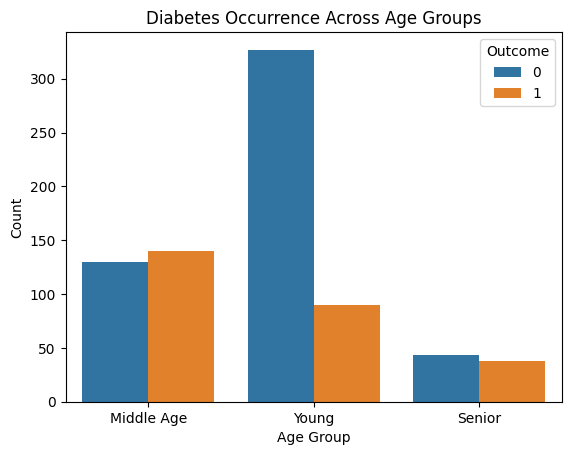

In [28]:
#Analyze Diabetes Occurrence Across Age Groups
age_outcome = pd.crosstab(
    df_processed['AgeGroup'],
    df_processed['Outcome'],
    normalize='index'
) * 100

print(age_outcome)
#Visualization:
sns.countplot(data=df_processed, x='AgeGroup', hue='Outcome')
plt.title("Diabetes Occurrence Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()


Part C: Exploratory Data Analysis (EDA)
Task 5: Univariate Analysis


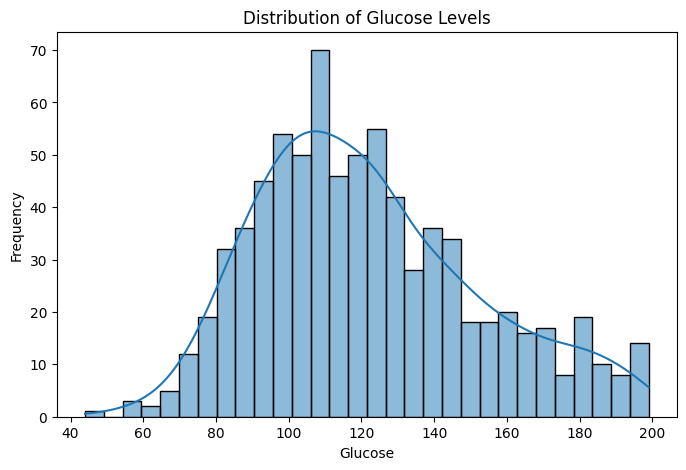

In [29]:
#Histogram of Glucose
plt.figure(figsize=(8, 5))

sns.histplot(df_processed['Glucose'], bins=30, kde=True)

plt.title("Distribution of Glucose Levels")
plt.xlabel("Glucose")
plt.ylabel("Frequency")

plt.show()


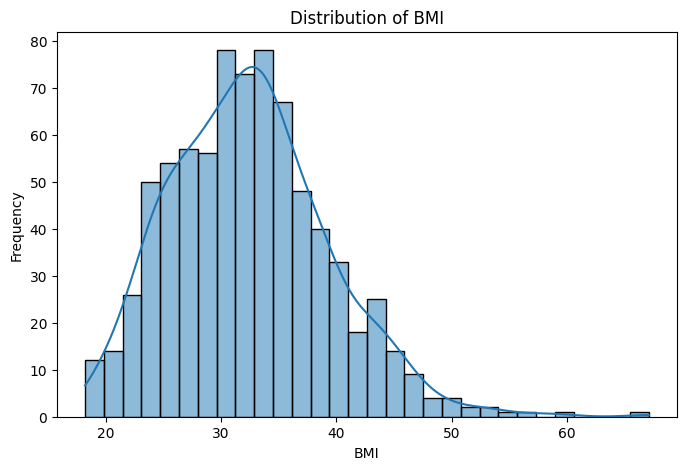

In [30]:
#Histogram of BMI
plt.figure(figsize=(8, 5))

sns.histplot(df_processed['BMI'], bins=30, kde=True)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()


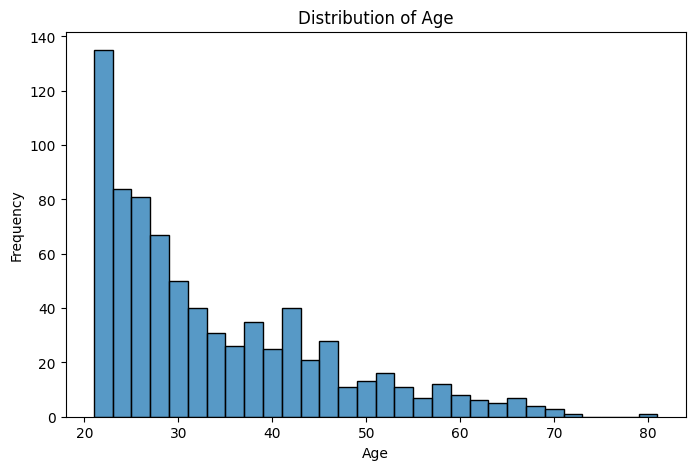

In [31]:
#Histogram of Age
plt.figure(figsize=(8, 5))

sns.histplot(df_processed['Age'], bins=30)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()


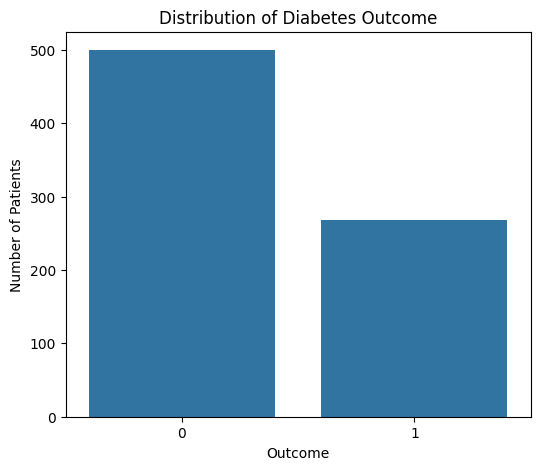

In [32]:
#Count Plot of Outcome
plt.figure(figsize=(6, 5))

sns.countplot(data=df_processed, x='Outcome')

plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()


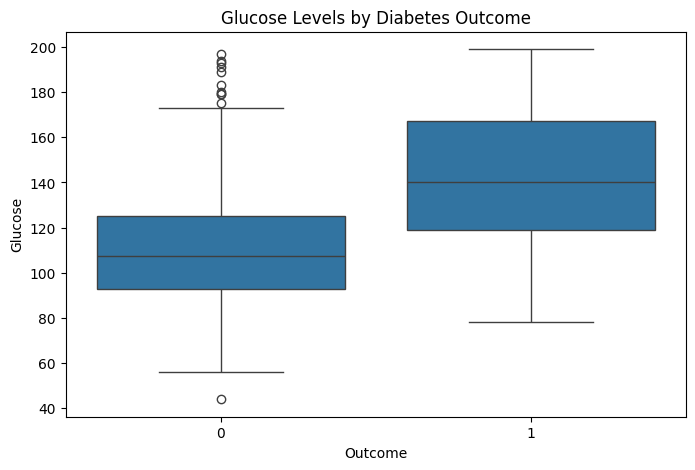

In [33]:
#Task 6: Bivariate Analysis
#Compare Glucose Levels by Outcome
plt.figure(figsize=(8, 5))

sns.boxplot(data=df_processed, x='Outcome', y='Glucose')

plt.title("Glucose Levels by Diabetes Outcome")

plt.show()


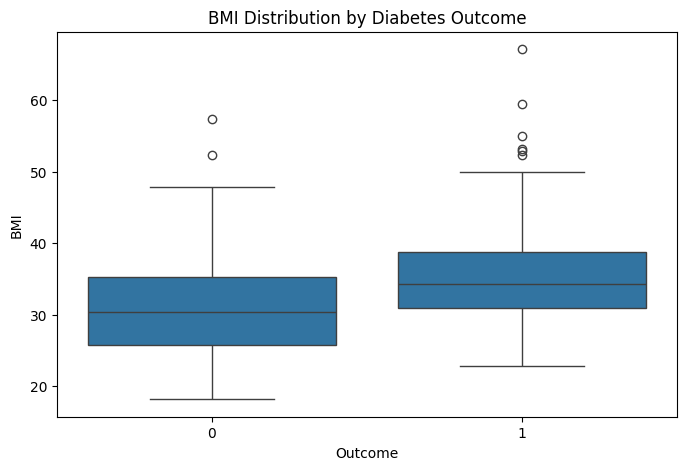

In [34]:
#Compare BMI Distribution by Outcome
plt.figure(figsize=(8, 5))

sns.boxplot(data=df_processed, x='Outcome', y='BMI')

plt.title("BMI Distribution by Diabetes Outcome")

plt.show()


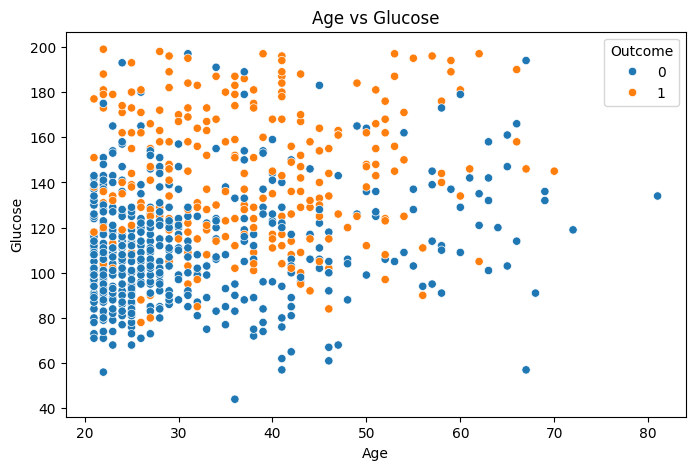

In [35]:
#Scatter Plot: Age vs Glucose
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_processed,
    x='Age',
    y='Glucose',
    hue='Outcome'
)

plt.title("Age vs Glucose")

plt.show()


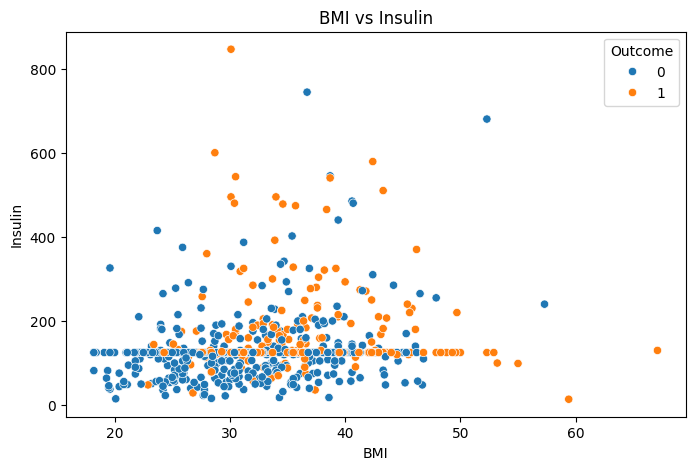

In [36]:
#Scatter Plot: BMI vs Insulin
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_processed,
    x='BMI',
    y='Insulin',
    hue='Outcome'
)

plt.title("BMI vs Insulin")

plt.show()


Task 7: Correlation Analysis
Compute Correlation Matrix

In [37]:
correlation_matrix = df_processed.drop(
    columns=['AgeGroup']
).corr()

print(correlation_matrix)


                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.128213       0.208615       0.081770   
Glucose                      0.128213  1.000000       0.218937       0.192615   
BloodPressure                0.208615  0.218937       1.000000       0.191892   
SkinThickness                0.081770  0.192615       0.191892       1.000000   
Insulin                      0.025047  0.419451       0.045363       0.155610   
BMI                          0.021559  0.231049       0.281257       0.543205   
DiabetesPedigreeFunction    -0.033523  0.137327      -0.002378       0.102188   
Age                          0.544341  0.266909       0.324915       0.126107   
Outcome                      0.221898  0.492782       0.165723       0.214873   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies               0.025047  0.021559                 -0.033523   
Glucose                   0.419451  0.231

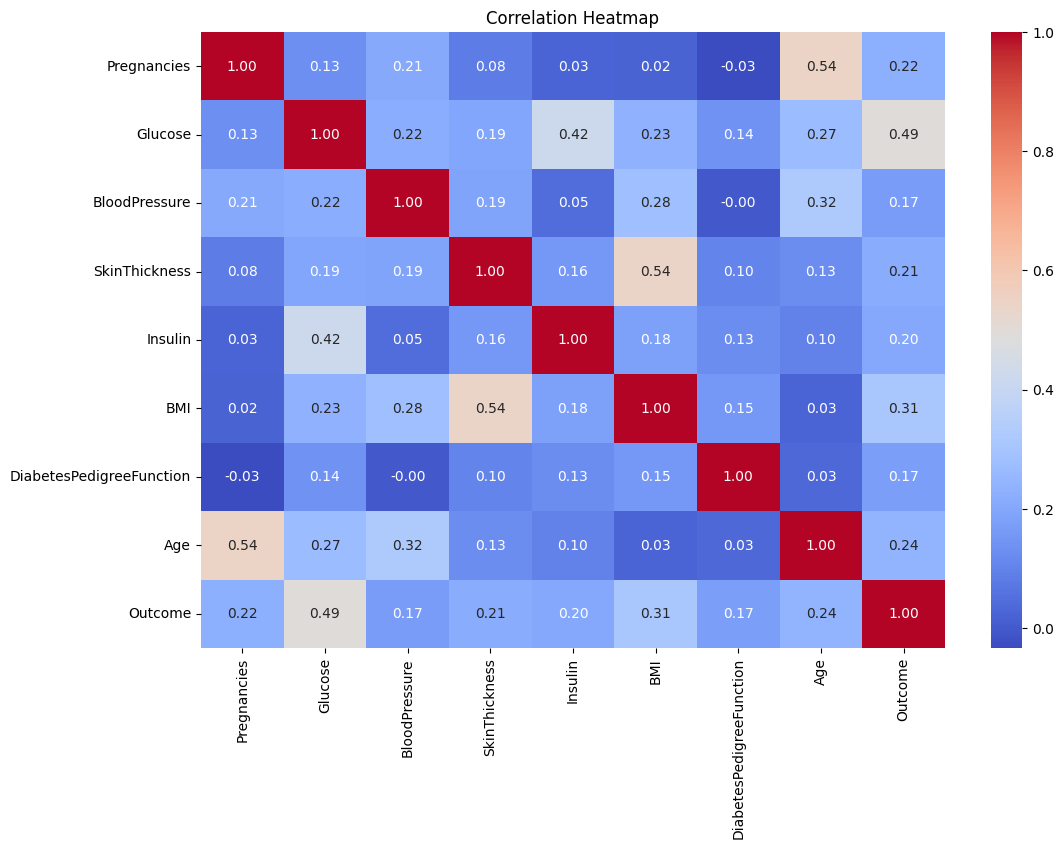

In [38]:
#Correlation Heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()


In [39]:
# Find Features Correlated with Outcome
outcome_correlation = correlation_matrix['Outcome'].sort_values(
    ascending=False
)

print(outcome_correlation)


Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64


Part D: Outlier Detection and Removal
Task 8: Outlier Detection Using IQR Method


In [41]:
outlier_columns = [
    'Glucose',
    'BloodPressure',
    'BMI',
    'Insulin',
    'Age'
]
#Calculate Q1, Q3, IQR, and Outliers
iqr_results = {}

for column in outlier_columns:

    Q1 = df_processed[column].quantile(0.25)
    Q3 = df_processed[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_processed[
        (df_processed[column] < lower_bound) |
        (df_processed[column] > upper_bound)
    ]

    iqr_results[column] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers)
    }

iqr_table = pd.DataFrame(iqr_results).T

print(iqr_table)


                   Q1      Q3    IQR  Lower Bound  Upper Bound  Outlier Count
Glucose         99.75  140.25  40.50       39.000      201.000            0.0
BloodPressure   64.00   80.00  16.00       40.000      104.000           14.0
BMI             27.50   36.60   9.10       13.850       50.250            8.0
Insulin        121.50  127.25   5.75      112.875      135.875          346.0
Age             24.00   41.00  17.00       -1.500       66.500            9.0


Task 9: Outlier Visualization


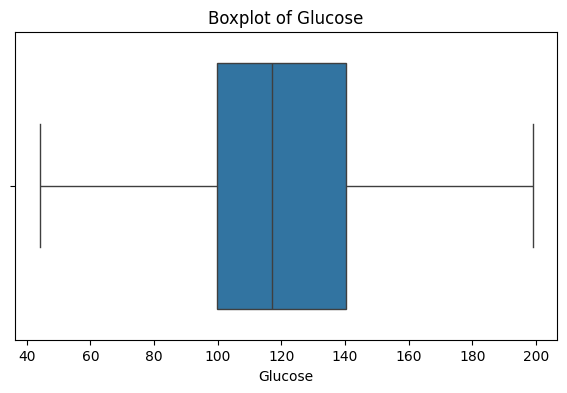

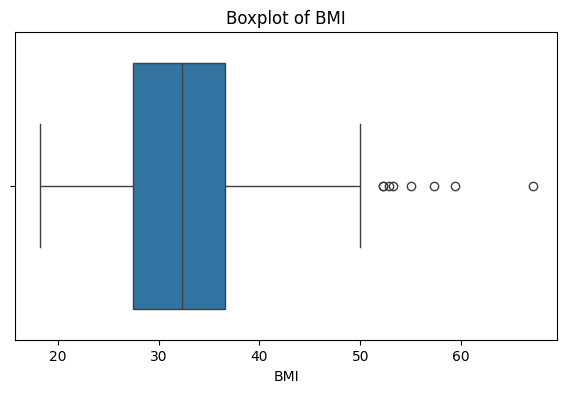

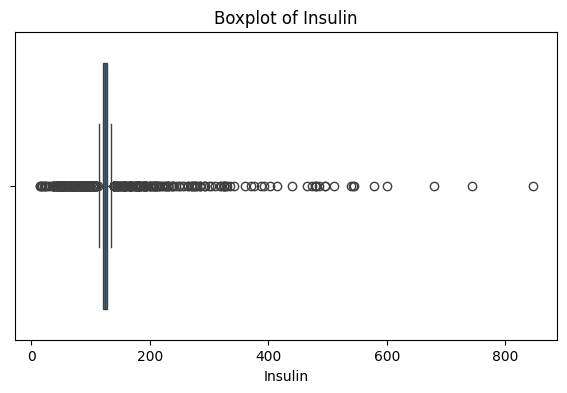

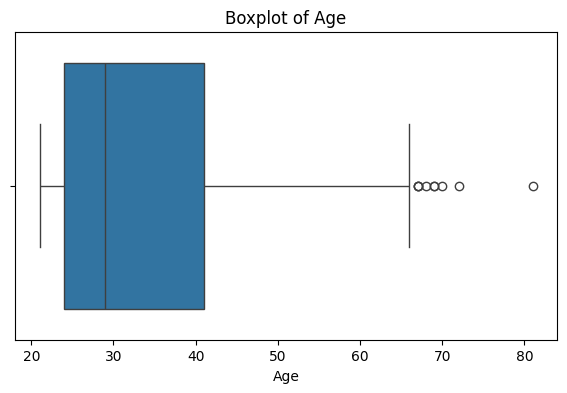

In [42]:
#Boxplot of Glucose
plt.figure(figsize=(7, 4))
sns.boxplot(x=df_processed['Glucose'])
plt.title("Boxplot of Glucose")
plt.show()
#Boxplot of BMI
plt.figure(figsize=(7, 4))
sns.boxplot(x=df_processed['BMI'])
plt.title("Boxplot of BMI")
plt.show()
#Boxplot of Insulin
plt.figure(figsize=(7, 4))
sns.boxplot(x=df_processed['Insulin'])
plt.title("Boxplot of Insulin")
plt.show()
#Boxplot of Age
plt.figure(figsize=(7, 4))
sns.boxplot(x=df_processed['Age'])
plt.title("Boxplot of Age")
plt.show()


Task 10: Outlier Removal Using IQR


In [43]:
print("Before Outlier Removal:", df_processed.shape)

#Remove Outliers
df_no_outliers = df_processed.copy()

for column in outlier_columns:

    Q1 = df_no_outliers[column].quantile(0.25)
    Q3 = df_no_outliers[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_no_outliers = df_no_outliers[
        (df_no_outliers[column] >= lower_bound) &
        (df_no_outliers[column] <= upper_bound)
    ]


Before Outlier Removal: (768, 10)


In [44]:
#Compare Dataset Dimensions
print("Before:", df_processed.shape)
print("After:", df_no_outliers.shape)


Before: (768, 10)
After: (390, 10)


In [45]:
#Calculate Percentage of Records Removed
records_before = df_processed.shape[0]
records_after = df_no_outliers.shape[0]

percentage_removed = (
    (records_before - records_after) /
    records_before
) * 100

print("Percentage of Records Removed:",
      round(percentage_removed, 2), "%")


Percentage of Records Removed: 49.22 %


In [46]:
#Compare Mean and Median Before and After
comparison_stats = pd.DataFrame({
    'Before Mean': df_processed[outlier_columns].mean(),
    'After Mean': df_no_outliers[outlier_columns].mean(),
    'Before Median': df_processed[outlier_columns].median(),
    'After Median': df_no_outliers[outlier_columns].median()
})

print(comparison_stats)


               Before Mean  After Mean  Before Median  After Median
Glucose         121.656250  121.184615          117.0         116.0
BloodPressure    72.386719   73.241026           72.0          72.0
BMI              32.455208   31.725641           32.3          31.6
Insulin         140.671875  125.048718          125.0         125.0
Age              33.240885   35.015385           29.0          32.0


Task 11: Z-Score Method


In [49]:
#Detect Outliers Using Z-Score
zscore_data = df_processed[outlier_columns]

z_scores = np.abs(stats.zscore(zscore_data))

zscore_outliers = (z_scores > 3)

outlier_count_zscore = zscore_outliers.sum(axis=0)

print("Outliers detected using Z-score:")
print(outlier_count_zscore)

#Count Rows Containing Z-Score Outliers
rows_with_outliers = (z_scores > 3).any(axis=1)

print(
    "Total rows containing Z-score outliers:",
    rows_with_outliers.sum()
)



Outliers detected using Z-score:
[ 0  8  5 20  5]
Total rows containing Z-score outliers: 36


Part E: Required Visualizations


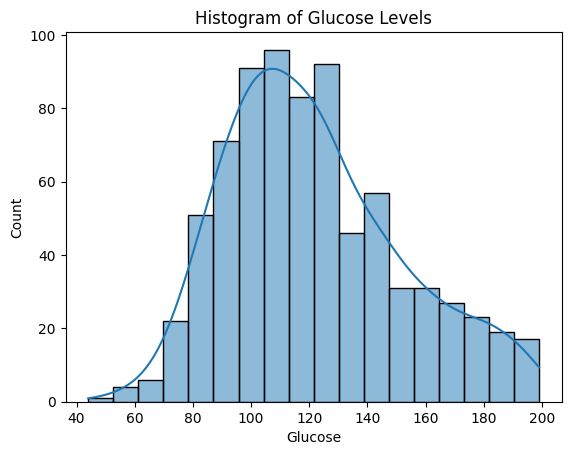

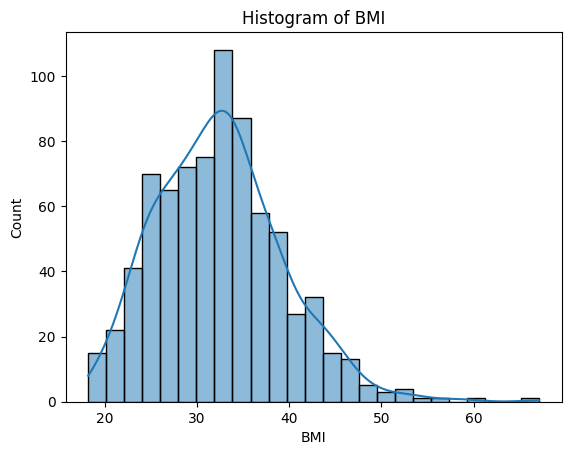

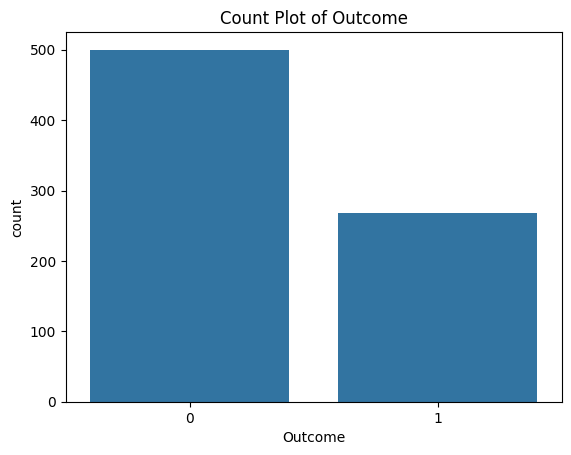

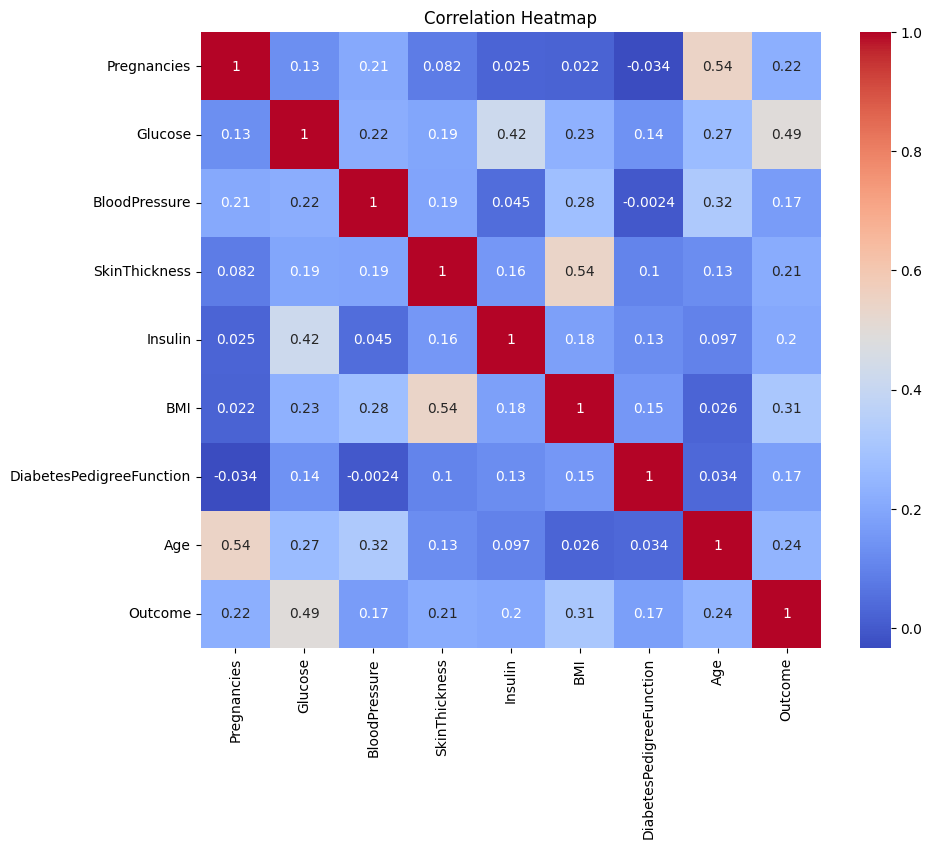

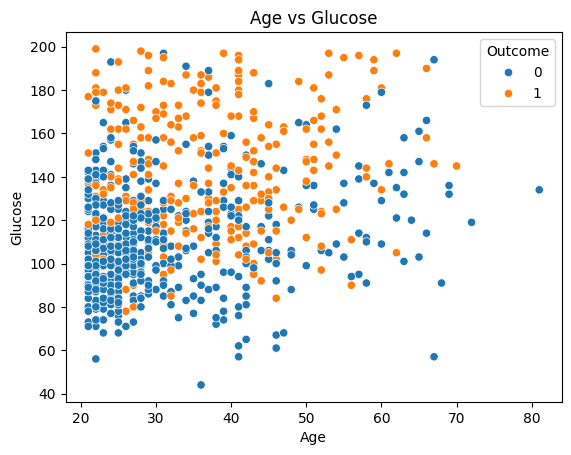

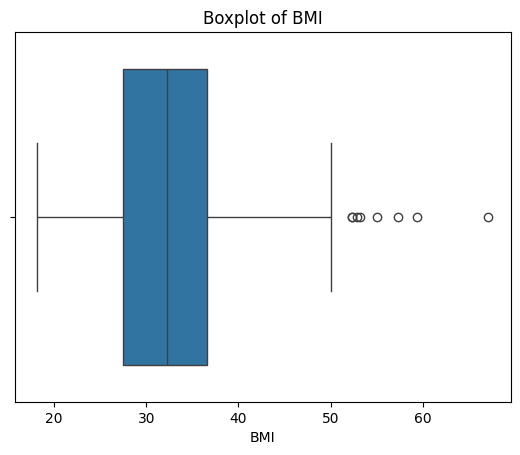

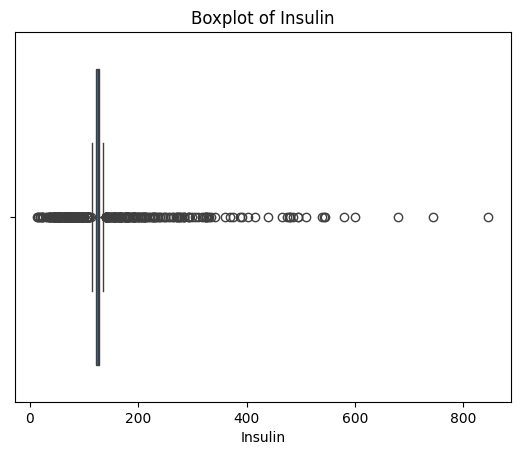

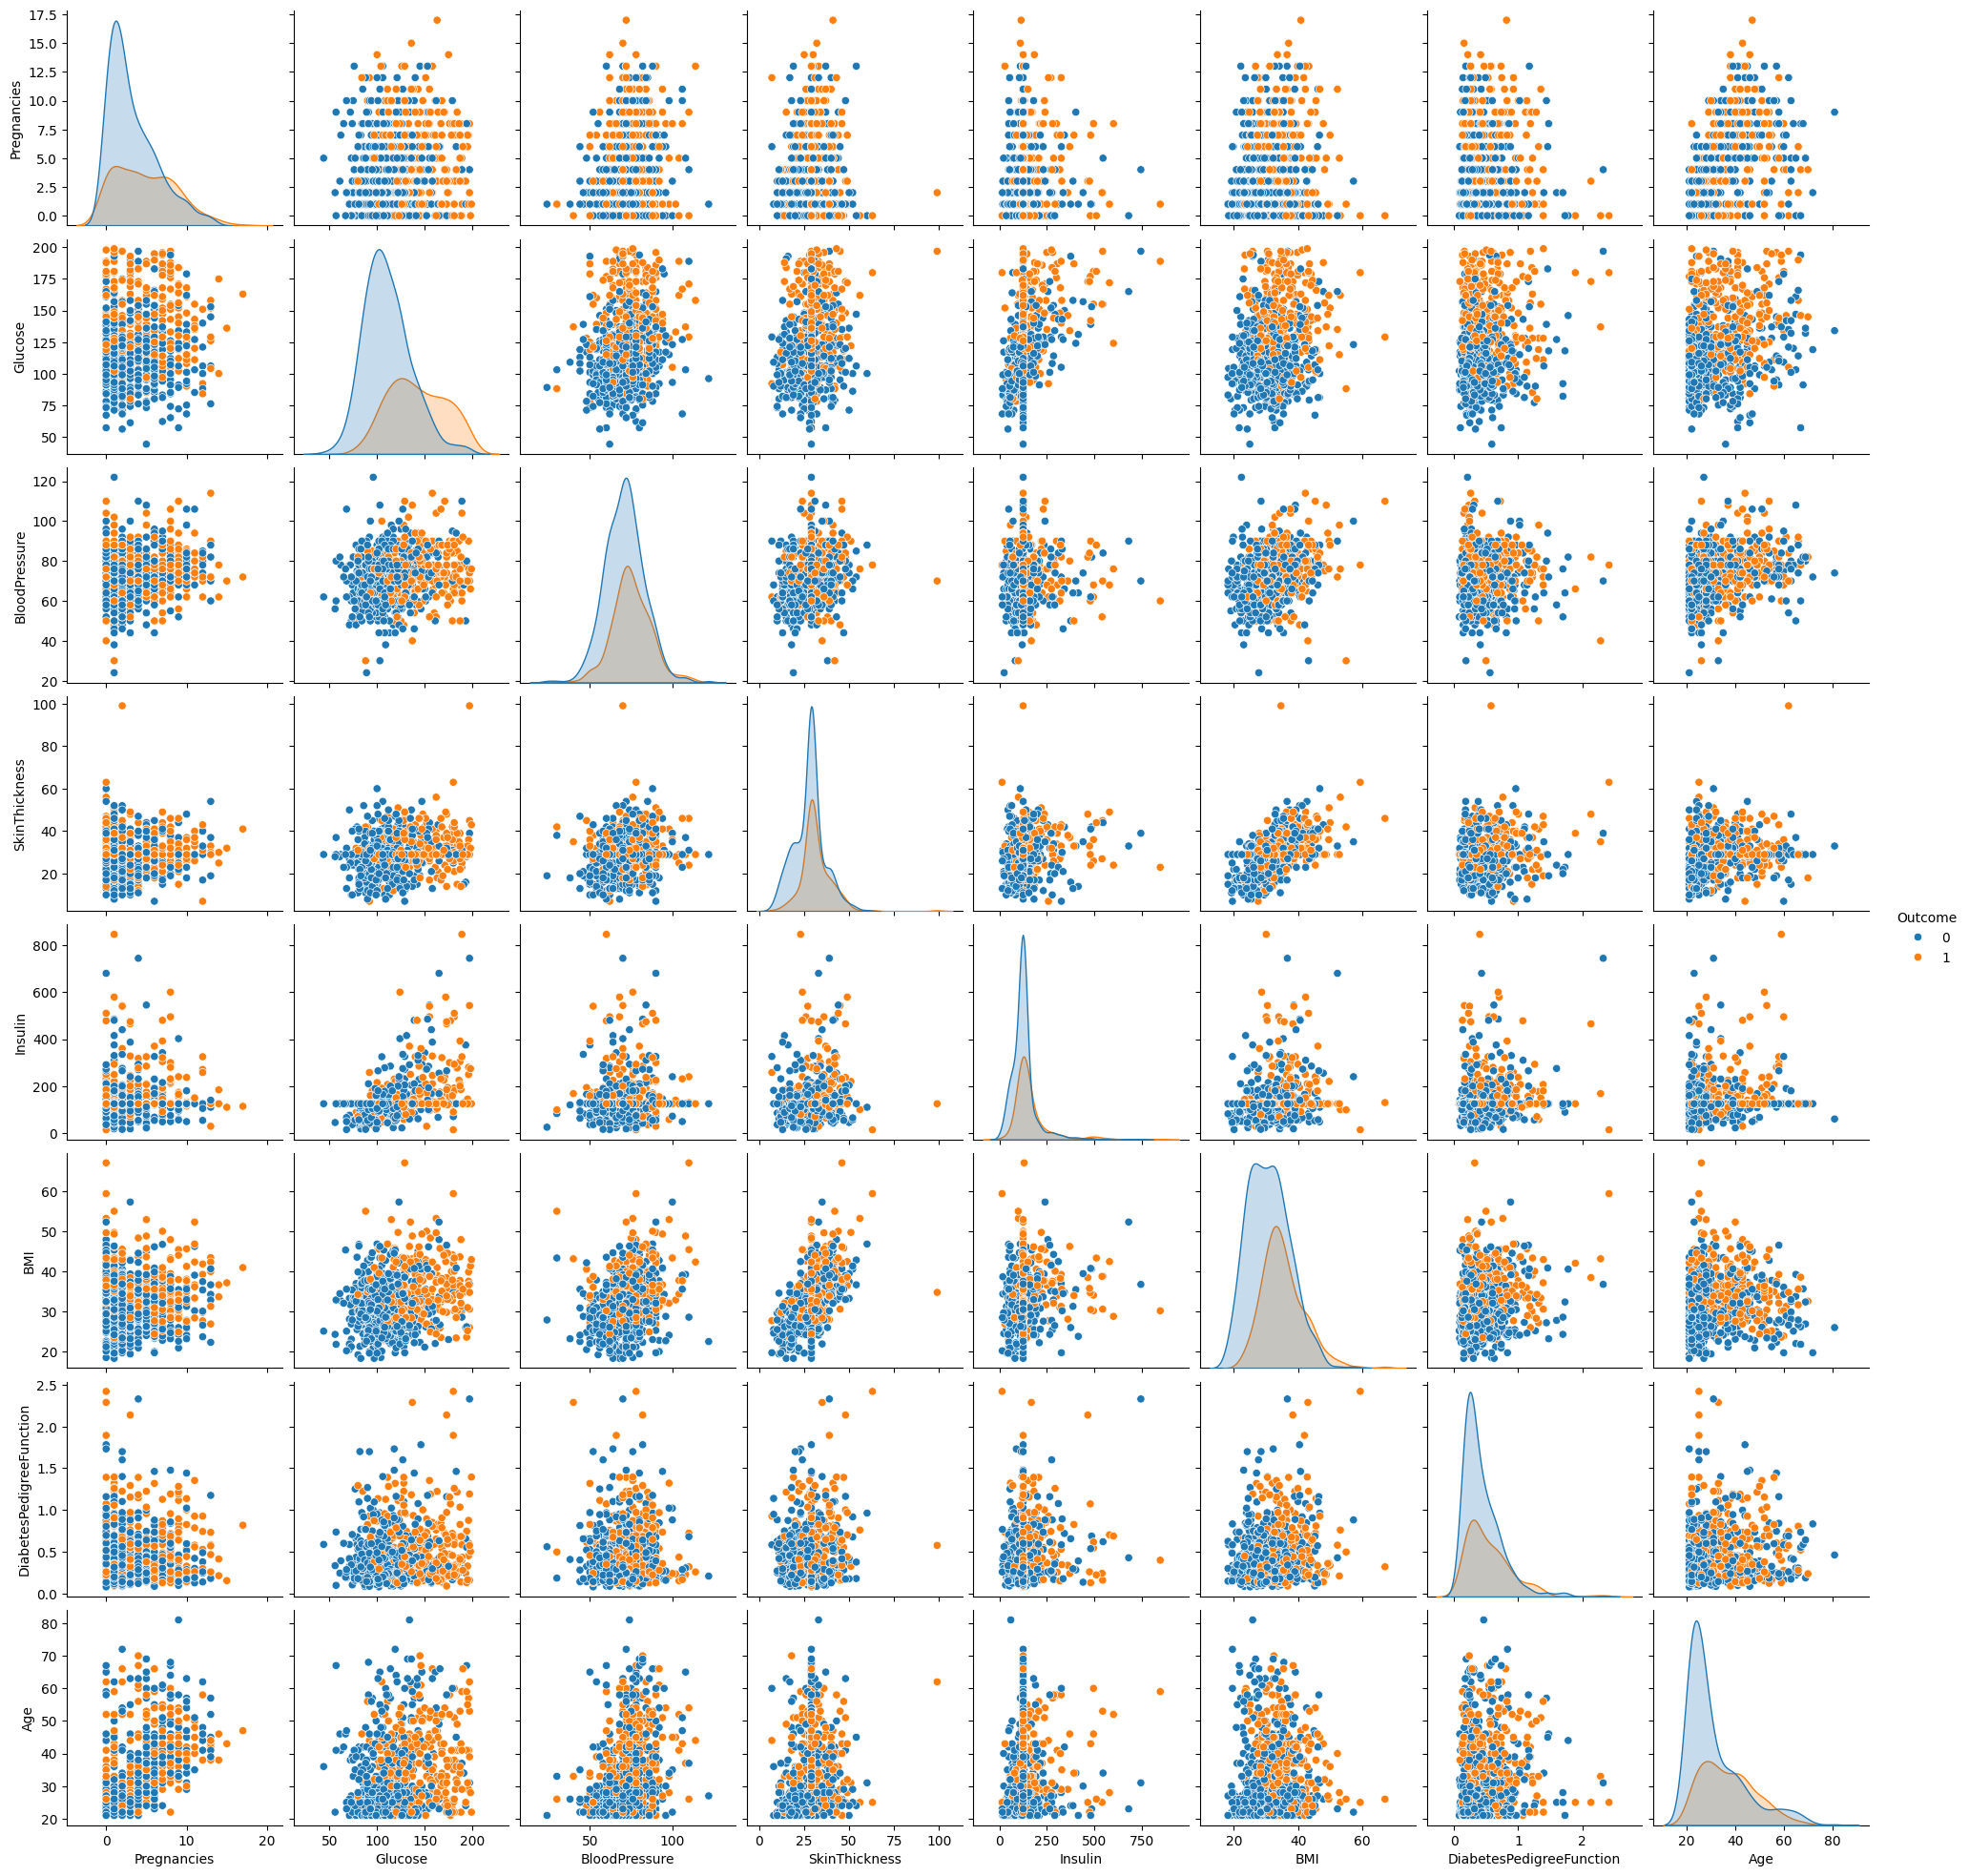

In [50]:
#1. Histogram of Glucose
sns.histplot(df_processed['Glucose'], kde=True)
plt.title("Histogram of Glucose Levels")
plt.show()
#2. Histogram of BMI
sns.histplot(df_processed['BMI'], kde=True)
plt.title("Histogram of BMI")
plt.show()
#3. Count Plot of Outcome
sns.countplot(data=df_processed, x='Outcome')
plt.title("Count Plot of Outcome")
plt.show()
#4. Correlation Heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    df_processed.drop(columns=['AgeGroup']).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()
#5. Scatter Plot: Age vs Glucose
sns.scatterplot(
    data=df_processed,
    x='Age',
    y='Glucose',
    hue='Outcome'
)

plt.title("Age vs Glucose")
plt.show()
#6. Boxplot: BMI
sns.boxplot(x=df_processed['BMI'])
plt.title("Boxplot of BMI")
plt.show()
#7. Boxplot: Insulin
sns.boxplot(x=df_processed['Insulin'])
plt.title("Boxplot of Insulin")
plt.show()
#8. Pair Plot of Numerical Features
sns.pairplot(
    df_processed.drop(columns=['AgeGroup']),
    hue='Outcome'
)

plt.show()




Part F: Analytical Questions
